# Genetic Algorithm for Autoencoder Optimization

This notebook implements a **NEAT**-inspired **(NeuroEvolution of Augmenting Topologies)** genetic algorithm to automatically discover optimal autoencoder architectures for  the *MovieLens* dataset. \
Instead of manually designing the autoencoder, evolution discovers that a simple 1-layer encoder with 32-dimensional embeddings achieves excellent results. \
The learned embeddings power a content-based recommendation system that produces intuitive, high-quality suggestions. \
The recommendation tests (cells 11-22) validate that the evolved embeddings capture meaningful movie similarities across genres, themes, and styles.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')
import random

2026-03-03 18:31:28.450627: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 18:31:28.794038: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 18:31:30.200592: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f'All seeds set to {SEED}')

All seeds set to 42


### 1. Loading the data created in the `01_data_preparation.ipynb` notebook

In [3]:
X_train = np.load('../models/X_train.npy')
X_val   = np.load('../models/X_val.npy')

dim = X_train.shape[1]
print(f'Train : {X_train.shape}   Val : {X_val.shape}')
print(f'Input dimension: {dim}')

Train : (8739, 57)   Val : (972, 57)
Input dimension: 57


### 2. Defining an **individual** in the population - represents one **autoencoder** architecture and its performance

In [4]:
class Individual:
    def __init__(self, input_dim, chromosome=None):
        self.input_dim = input_dim
        if chromosome is None:
            self.chromosome = self.minimal_chromosome()
        else:
            self.chromosome = chromosome
        self.model = None
        self.fitness = None
        self.val_loss = None
        self.complexity = self.calculate_complexity()

    # NEAT approach: start with a minimal autoencoder (1 encoder layer), complexity will evolve eventually
    @staticmethod
    def minimal_chromosome():
        return {
            'num_layers': 1,
            'layer_sizes': [64],
            'activations': ['relu'],
            'dropout_rates': [0.1],
            'embedding_dim': 32,
            'learning_rate': 0.001,
            'batch_size': 128,
        }

    # Calculate network complexity for fitness penalty
    def calculate_complexity(self):
        c = self.chromosome

        # Encoder: input => hidden layers => embedding
        sizes = [self.input_dim] + c['layer_sizes'] + [c['embedding_dim']]
        num_params = sum(sizes[i] * sizes[i+1] for i in range(len(sizes) - 1))  # for minimal chromosome, this calculates 57*64 + 64*32

        # Decoder mirrors the encoder
        num_params *= 2

        # Final reconstruction layer: embedding => input
        # FIXME: potencijalno duplo ubraja za reconstruction layer, proveri celu klasu
        num_params += c['embedding_dim'] * self.input_dim

        return num_params

    # Build a symmetric autoencoder from chromosome
    def build_model(self):
        c = self.chromosome
        inp = layers.Input(shape=(self.input_dim,))
        x = inp

        # Encoder
        for i in range(c['num_layers']):
            x = layers.Dense(c['layer_sizes'][i], activation=c['activations'][i])(x)
            x = layers.Dropout(c['dropout_rates'][i])(x)
        embed = layers.Dense(c['embedding_dim'], activation='relu', name='embedding')(x)

        # Decoder (mirrors encoder)
        x = embed
        for i in range(c['num_layers'] - 1, -1, -1):
            x = layers.Dense(c['layer_sizes'][i], activation=c['activations'][i])(x)
            x = layers.Dropout(c['dropout_rates'][i])(x)
        out = layers.Dense(self.input_dim, activation='linear', name='reconstruction')(x)

        model = keras.Model(inputs=inp, outputs=out)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=c['learning_rate']),
            loss='mse',
            metrics=['mae']
        )
        self.model = model

        return model

    def calc_fitness(self, x_train, x_val, epochs=10, complexity_penalty=0.00001):
        if self.model is None:
            self.build_model()

        # Early stopping
        early_stop = keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )

        # Train (autoencoder reconstructs its own input)
        history = self.model.fit(
            x_train, x_train,
            validation_data=(x_val, x_val),
            epochs=epochs,
            batch_size=self.chromosome['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Get the best validation loss
        val_loss = min(history.history['val_loss'])

        # Penalize complexity (prefer simpler networks)
        self.complexity = self.calculate_complexity()
        complexity_cost = complexity_penalty * self.complexity

        # Fitness = performance - complexity
        self.fitness = -(val_loss + complexity_cost)
        self.val_loss = val_loss

        return self.fitness

    def __lt__(self, other):
        return self.fitness < other.fitness

    def __repr__(self):
        return f"NEAT(fit={self.fitness:.4f}, loss={self.val_loss:.4f}, layers={self.chromosome['num_layers']}, embed={self.chromosome['embedding_dim']}, params={self.complexity})"

In [5]:
class GeneticAlgorithm:
    def __init__(
        self,
        population_size: int,
        num_generations: int,
        mutation_prob: float,
        add_node_prob: float,  # Probability of adding a layer
        elitism_size: float,
        selection_type: str = 'tournament',
        tournament_size: int = 3,
        training_epochs: int = 10,
        complexity_penalty: float = 0.00001,
    ):
        self.population_size = population_size
        self.num_elite = int(population_size * elitism_size)
        if self.num_elite % 2 != self.population_size % 2:
            self.num_elite += 1
        self.mutation_prob = mutation_prob
        self.add_node_prob = add_node_prob  # NEAT: structural mutation
        self.selection_type = selection_type
        self.tournament_size = tournament_size
        self.num_generations = num_generations
        self.training_epochs = training_epochs
        self.complexity_penalty = complexity_penalty

        self.history = {
        'best_fitness': [],
        'best_val_loss': [],
        'avg_complexity': [],
        'avg_layers': [],
        }

    def selection(self, population):
        if self.selection_type == 'tournament':
            participants = random.sample(population, self.tournament_size)
            return max(participants, key=lambda x: x.fitness)
        else:
            raise ValueError(f'unknown selection_type: {self.selection_type}')

    @staticmethod
    def crossover(parent1, parent2):
        fitter = parent1 if parent1.fitness > parent2.fitness else parent2
        weaker = parent2 if parent1.fitness > parent2.fitness else parent1

        # Start with fitter parent's structure
        child_chromo = deepcopy(fitter.chromosome)

        # Randomly inherit some traits from weaker parent
        if random.random() < 0.3:
            child_chromo['learning_rate'] = weaker.chromosome['learning_rate']

        if random.random() < 0.3:
            child_chromo['batch_size'] = weaker.chromosome['batch_size']

        if random.random() < 0.3:
            child_chromo['embedding_dim'] = weaker.chromosome['embedding_dim']

        # For layers that exist in both, maybe swap
        min_layers = min(len(parent1.chromosome['layer_sizes']),
                        len(parent2.chromosome['layer_sizes']))

        for i in range(min_layers):
            if random.random() < 0.3:
                child_chromo['layer_sizes'][i] = weaker.chromosome['layer_sizes'][i]
                child_chromo['activations'][i] = weaker.chromosome['activations'][i]
                child_chromo['dropout_rates'][i] = weaker.chromosome['dropout_rates'][i]

        return child_chromo

    # Add or remove layers
    def structural_mutation(self, chromosome):
        mutated = deepcopy(chromosome)

        if random.random() < self.add_node_prob:
            if mutated['num_layers'] < 5:  # Max 5 encoder layers
                mutated['num_layers'] += 1
                new_size = random.choice([64, 128])
                mutated['layer_sizes'].append(new_size)
                mutated['activations'].append('relu')
                mutated['dropout_rates'].append(random.uniform(0.2, 0.4))
                print(f"\tAdded layer! Now {mutated['num_layers']} layers", flush=True)

        elif random.random() < self.add_node_prob * 0.3:  # 30% chance compared to adding
            if mutated['num_layers'] > 1:
                mutated['num_layers'] -= 1
                mutated['layer_sizes'].pop()
                mutated['activations'].pop()
                mutated['dropout_rates'].pop()
                print(f"\tRemoved layer! Now {mutated['num_layers']} layers", flush=True)

        return mutated

    # Regular mutation
    def parameter_mutation(self, chromosome):
        mutated = deepcopy(chromosome)

        # Mutate learning rate
        if random.random() < self.mutation_prob:
            mutated['learning_rate'] = random.choice([0.0005, 0.001, 0.005])

        # Mutate batch size
        if random.random() < self.mutation_prob:
            mutated['batch_size'] = random.choice([128, 256])

        # Mutate embedding dim
        if random.random() < self.mutation_prob:
            mutated['embedding_dim'] = random.choice([16, 32, 64])

        # Mutate existing layers
        for i in range(len(mutated['layer_sizes'])):
            if random.random() < self.mutation_prob:
                mutated['layer_sizes'][i] = random.choice([64, 128, 256])

            if random.random() < self.mutation_prob:
                mutated['activations'][i] = random.choice(['relu', 'tanh'])

            if random.random() < self.mutation_prob:
                mutated['dropout_rates'][i] = random.uniform(0.2, 0.4)

        return mutated

    def solve(self, x_train, x_val):
        input_dim = x_train.shape[1]

        print(f"--- Starting evolution...")
        print(f"--- Population: {self.population_size}, Generations: {self.num_generations}")
        print(f"--- Starting with MINIMAL topology (1 encoder layer)\n")

        population = [Individual(input_dim) for _ in range(self.population_size)]

        # Evaluate initial population
        print("--- Evaluating minimal networks...")
        for i, ind in enumerate(population):
            ind.calc_fitness(x_train, x_val,
                           epochs=self.training_epochs,
                           complexity_penalty=self.complexity_penalty)
            print(f"\t[{i+1}/{self.population_size}] {ind}")

        best_overall = max(population, key=lambda x: x.fitness)

        # Evolution
        for gen in range(self.num_generations):
            print(f"\n{'='*70}")
            print(f"--- Generation {gen+1}/{self.num_generations}")
            print(f"{'='*70}")

            population.sort(reverse=True, key=lambda x: x.fitness)

            # Statistics
            avg_layers = np.mean([ind.chromosome['num_layers'] for ind in population])
            avg_complexity = np.mean([ind.complexity for ind in population])

            self.history['avg_layers'].append(avg_layers)
            self.history['avg_complexity'].append(avg_complexity)
            self.history['best_fitness'].append(population[0].fitness)
            self.history['best_val_loss'].append(population[0].val_loss)

            new_population = population[:self.num_elite]

            print(f"--- Top 3:")
            for i, ind in enumerate(population[:3]):
                print(f"  {i+1}. {ind}")

            print(f"\n--- Population Stats:")
            print(f"\tAvg Layers: {avg_layers:.2f}")
            print(f"\tAvg Params: {avg_complexity:.0f}")
            print(f"\tComplexity Range: {min(ind.complexity for ind in population)} - {max(ind.complexity for ind in population)}")

            # Generate children
            print(f"\n--- Generating children...")
            for i in range(self.num_elite, self.population_size):
                parent1 = self.selection(population)
                parent2 = self.selection(population)

                child_chromo = self.crossover(parent1, parent2)
                child_chromo = self.structural_mutation(child_chromo)
                child_chromo = self.parameter_mutation(child_chromo)

                child = Individual(input_dim, child_chromo)
                child.calc_fitness(x_train, x_val,
                                 epochs=self.training_epochs,
                                 complexity_penalty=self.complexity_penalty)

                print(f"\tChild {i-self.num_elite+1}: {child}")
                new_population.append(child)

            population = new_population

            current_best = max(population, key=lambda x: x.fitness)
            if current_best.fitness > best_overall.fitness:
                best_overall = deepcopy(current_best)
                print(f"\n\tNEW BEST: {best_overall}")

        return best_overall

In [6]:
SAMPLE_N = 5000
idx = np.random.choice(len(X_train), min(SAMPLE_N, len(X_train)), replace=False)
X_train_sample = X_train[idx]
X_val_sample   = X_val[:1000]

print(f'GA training sample: {X_train_sample.shape}')
print(f'GA val sample: {X_val_sample.shape}')

GA training sample: (5000, 57)
GA val sample: (972, 57)


In [7]:
ga = GeneticAlgorithm(
    population_size = 10,
    num_generations = 8,
    mutation_prob = 0.2,
    add_node_prob = 0.3,
    elitism_size = 0.2,
    selection_type = 'tournament',
    tournament_size = 3,
    training_epochs = 12,
    complexity_penalty = 0.000001,
)

best = ga.solve(X_train_sample, X_val_sample)

print('\n' + '='*65)
print('EVOLUTION COMPLETE')
print('='*65)
print(f'Best chromosome: {best.chromosome}')

--- Starting evolution...
--- Population: 10, Generations: 8
--- Starting with MINIMAL topology (1 encoder layer)

--- Evaluating minimal networks...
	[1/10] NEAT(fit=-0.0277, loss=0.0144, layers=1, embed=32, params=13216)
	[2/10] NEAT(fit=-0.0285, loss=0.0153, layers=1, embed=32, params=13216)
	[3/10] NEAT(fit=-0.0279, loss=0.0146, layers=1, embed=32, params=13216)
	[4/10] NEAT(fit=-0.0289, loss=0.0157, layers=1, embed=32, params=13216)
	[5/10] NEAT(fit=-0.0279, loss=0.0147, layers=1, embed=32, params=13216)
	[6/10] NEAT(fit=-0.0279, loss=0.0147, layers=1, embed=32, params=13216)
	[7/10] NEAT(fit=-0.0278, loss=0.0146, layers=1, embed=32, params=13216)
	[8/10] NEAT(fit=-0.0278, loss=0.0145, layers=1, embed=32, params=13216)
	[9/10] NEAT(fit=-0.0268, loss=0.0136, layers=1, embed=32, params=13216)
	[10/10] NEAT(fit=-0.0275, loss=0.0143, layers=1, embed=32, params=13216)

--- Generation 1/8
--- Top 3:
  1. NEAT(fit=-0.0268, loss=0.0136, layers=1, embed=32, params=13216)
  2. NEAT(fit=-0.0

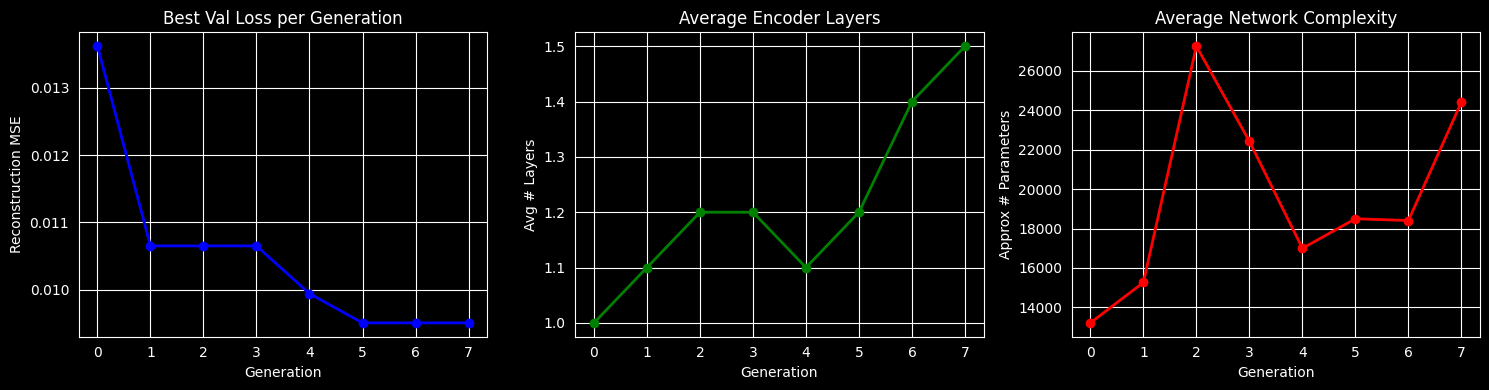

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(ga.history['best_val_loss'], 'b-o', linewidth=2)
axes[0].set_title('Best Val Loss per Generation')
axes[0].set_xlabel('Generation'); axes[0].set_ylabel('Reconstruction MSE')

axes[1].plot(ga.history['avg_layers'], 'g-o', linewidth=2)
axes[1].set_title('Average Encoder Layers')
axes[1].set_xlabel('Generation'); axes[1].set_ylabel('Avg # Layers')

axes[2].plot(ga.history['avg_complexity'], 'r-o', linewidth=2)
axes[2].set_title('Average Network Complexity')
axes[2].set_xlabel('Generation'); axes[2].set_ylabel('Approx # Parameters')

plt.tight_layout()
plt.show()

In [9]:
# Rebuild a fresh model with the best chromosome
best.model = None
best.build_model()
best.model.summary()

history_full = best.model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=best.chromosome['batch_size'],
    callbacks=[
        keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, min_lr=1e-5, verbose=1),
    ],
    verbose=1
)

final_val = min(history_full.history['val_loss'])
print(f'\nFinal val MSE: {final_val:.5f}')
print(f'Architecture: {best.chromosome["num_layers"]} encoder layers, embed_dim={best.chromosome["embedding_dim"]}')
print(f'Parameters: ~{best.complexity:,}')

Model: "functional_149"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_74 (InputLayer)     │ (None, 57)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_188 (Dense)               │ (None, 64)             │         3,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_188 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_189 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_189 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 57)             │         3,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,609 (45.35 KB)

 Trainable params: 11,609 (45.35 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0783 - mae: 0.1899 - val_loss: 0.0352 - val_mae: 0.1292 - learning_rate: 0.0010
Epoch 2/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0361 - mae: 0.1359 - val_loss: 0.0251 - val_mae: 0.1119 - learning_rate: 0.0010
Epoch 3/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0280 - mae: 0.1225 - val_loss: 0.0200 - val_mae: 0.1008 - learning_rate: 0.0010
Epoch 4/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0234 - mae: 0.1129 - val_loss: 0.0164 - val_mae: 0.0913 - learning_rate: 0.0010
Epoch 5/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0201 - mae: 0.1051 - val_loss: 0.0138 - val_mae: 0.0835 - learning_rate: 0.0010
Epoch 6/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0178 - mae: 0.0991 - val_loss: 0.0121 - val_mae: 0.0772 - learning_rate: 0.0010
Epoch 7/100
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0162 - mae: 0.0942 - val_loss: 0.0108 - val_mae: 0.0722 - learning_rate: 0.0010
Epoch 8/100
6

In [10]:
# Extract encoder from best autoencoder
inp = best.model.input
embed = best.model.get_layer('embedding').output
best_encoder = keras.Model(inputs=inp, outputs=embed, name='best_encoder')

# Generate new embeddings with the GA-optimised encoder
feature_df = pd.read_csv('../data/movie_features.csv')
with open('../data/feature_cols.txt') as f:
    feature_cols = f.read().splitlines()

X_all = feature_df[feature_cols].values.astype(np.float32)
embeds = best_encoder.predict(X_all, batch_size=256, verbose=0)
norms = np.linalg.norm(embeds, axis=1, keepdims=True) + 1e-8
embeddings_ga = embeds / norms

In [11]:
best_encoder.save('../models/best_encoder.keras')
np.save('../models/embeddings_ga.npy', embeddings_ga)

In [12]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend(liked_titles, top_n=10, df=feature_df, embeddings=embeddings_ga):
    liked_ids, liked_vecs = [], []
    for title in liked_titles:
        matches = df[df['title'].str.lower().str.contains(title.lower(), regex=False)]

        if matches.empty:
            print(f'  Warning: "{title}" not found => skipping')
            continue

        row = matches.iloc[0]
        liked_ids.append(row['movieId'])
        liked_vecs.append(embeddings[row.name])
        print(f'  Matched: {row["title"]} ({int(row["year"])})')

    if not liked_vecs:
        return pd.DataFrame()

    query  = np.mean(liked_vecs, axis=0, keepdims=True)
    query /= (np.linalg.norm(query) + 1e-8)

    sims   = cosine_similarity(query, embeddings)[0]

    result = df[['movieId','title','genres','year']].copy()
    result['similarity'] = sims
    result = result[~result['movieId'].isin(liked_ids)]
    result = result.sort_values('similarity', ascending=False).head(top_n)
    result['year'] = result['year'].astype(int)
    result['similarity'] = result['similarity'].round(4)

    return result.reset_index(drop=True)

print('Test: Inception + The Matrix\n')
recs = recommend(['Inception', 'Matrix'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

Test: Inception + The Matrix

  Matched: Inception (2010) (2010)
  Matched: Matrix, The (1999) (1999)
                       title                                    genres  year  similarity
       V for Vendetta (2006)               Action|Sci-Fi|Thriller|IMAX  2006      0.9847
      Minority Report (2002)      Action|Crime|Mystery|Sci-Fi|Thriller  2002      0.9822
             Watchmen (2009) Action|Drama|Mystery|Sci-Fi|Thriller|IMAX  2009      0.9810
X-Men: The Last Stand (2006)                    Action|Sci-Fi|Thriller  2006      0.9786
              RoboCop (1987)        Action|Crime|Drama|Sci-Fi|Thriller  1987      0.9781
      Terminator, The (1984)                    Action|Sci-Fi|Thriller  1984      0.9768
          Source Code (2011)      Action|Drama|Mystery|Sci-Fi|Thriller  2011      0.9764
             Predator (1987)                    Action|Sci-Fi|Thriller  1987      0.9749
         Transformers (2007)               Action|Sci-Fi|Thriller|IMAX  2007      0.9749
        

In [13]:
recs = recommend(['Interstellar'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Interstellar (2014) (2014)
                                              title             genres  year  similarity
                                     Arrival (2016)             Sci-Fi  2016      0.9804
                           Blade Runner 2049 (2017)             Sci-Fi  2017      0.9776
                                 Cloud Atlas (2012)  Drama|Sci-Fi|IMAX  2012      0.9645
                                     Gravity (2013) Action|Sci-Fi|IMAX  2013      0.9642
                            Edge of Tomorrow (2014) Action|Sci-Fi|IMAX  2014      0.9641
              Dawn of the Planet of the Apes (2014)             Sci-Fi  2014      0.9572
                                       Logan (2017)      Action|Sci-Fi  2017      0.9543
Frequently Asked Questions About Time Travel (2009)      Comedy|Sci-Fi  2009      0.9510
                                       Dredd (2012)      Action|Sci-Fi  2012      0.9508
                               Transcendence (2014)  Drama|Sci-Fi|IMAX  

In [14]:
recs = recommend(['Good Will Hunting', 'Prestige', 'Interstellar'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Good Will Hunting (1997) (1997)
  Matched: Prestige, The (2006) (2006)
  Matched: Interstellar (2014) (2014)
                                       title                                    genres  year  similarity
Eternal Sunshine of the Spotless Mind (2004)                      Drama|Romance|Sci-Fi  2004      0.9678
                          Cloud Atlas (2012)                         Drama|Sci-Fi|IMAX  2012      0.9674
                                  Her (2013)                      Drama|Romance|Sci-Fi  2013      0.9655
                         Donnie Darko (2001)             Drama|Mystery|Sci-Fi|Thriller  2001      0.9652
                          Unbreakable (2000)                              Drama|Sci-Fi  2000      0.9621
                             Watchmen (2009) Action|Drama|Mystery|Sci-Fi|Thriller|IMAX  2009      0.9601
                                 Moon (2009)             Drama|Mystery|Sci-Fi|Thriller  2009      0.9597
                     Truman Show, The (1

In [15]:
recs = recommend(['Loving Vincent', 'Ameli', 'Princess Mononoke'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Loving Vincent (2017) (2017)
  Matched: Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001) (2001)
  Matched: Princess Mononoke (Mononoke-hime) (1997) (1997)
                                                            title                                              genres  year  similarity
                                         World of Tomorrow (2015)                                    Animation|Comedy  2015      0.9626
                                              Mary and Max (2009)                              Animation|Comedy|Drama  2009      0.9615
                                       Simpsons Movie, The (2007)                                    Animation|Comedy  2007      0.9585
                                              Lesson Faust (1994)                      Animation|Comedy|Drama|Fantasy  1994      0.9572
                                                     Shrek (2001) Adventure|Animation|Children|Comedy|Fantasy|Romance  2001      0.9569
              

In [16]:
recs = recommend(['La vie en rose', 'Lord of the rings', 'The hunger games'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Lord of the Rings, The (1978) (1978)
  Matched: The Hunger Games (2012) (2012)
                                                    title                                             genres  year  similarity
Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986) Action|Adventure|Animation|Children|Fantasy|Sci-Fi  1986      0.9756
                                         Space Jam (1996) Adventure|Animation|Children|Comedy|Fantasy|Sci-Fi  1996      0.9715
                                        Titan A.E. (2000)         Action|Adventure|Animation|Children|Sci-Fi  2000      0.9677
                                   Iron Giant, The (1999)          Adventure|Animation|Children|Drama|Sci-Fi  1999      0.9668
                                        Inside Out (2015)  Adventure|Animation|Children|Comedy|Drama|Fantasy  2015      0.9636
                                    The Lego Movie (2014) Action|Adventure|Animation|Children|Comedy|Fantasy  2014      0.9631
                     

In [17]:
recs = recommend(['inception', 'interstellar', 'matrix'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Inception (2010) (2010)
  Matched: Interstellar (2014) (2014)
  Matched: Matrix, The (1999) (1999)
                          title                                    genres  year  similarity
          V for Vendetta (2006)               Action|Sci-Fi|Thriller|IMAX  2006      0.9841
            Transformers (2007)               Action|Sci-Fi|Thriller|IMAX  2007      0.9747
   X-Men: The Last Stand (2006)                    Action|Sci-Fi|Thriller  2006      0.9745
              Iron Man 3 (2013)               Action|Sci-Fi|Thriller|IMAX  2013      0.9741
                Watchmen (2009) Action|Drama|Mystery|Sci-Fi|Thriller|IMAX  2009      0.9741
                    2012 (2009)              Action|Drama|Sci-Fi|Thriller  2009      0.9714
              Battleship (2012)               Action|Sci-Fi|Thriller|IMAX  2012      0.9709
             Equilibrium (2002)                    Action|Sci-Fi|Thriller  2002      0.9707
X-Men Origins: Wolverine (2009)                    Action|Sci-

In [18]:
recs = recommend(['oldboy', 'interstellar', 'ice age'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Oldboy (2013) (2013)
  Matched: Interstellar (2014) (2014)
  Matched: Ice Age (2002) (2002)
                  title                                                 genres  year  similarity
        Megamind (2010)           Action|Animation|Children|Comedy|Sci-Fi|IMAX  2010      0.9671
   Kung Fu Panda (2008)                  Action|Animation|Children|Comedy|IMAX  2008      0.9621
 Kung Fu Panda 2 (2011)        Action|Adventure|Animation|Children|Comedy|IMAX  2011      0.9593
 Mars Needs Moms (2011) Action|Adventure|Animation|Children|Comedy|Sci-Fi|IMAX  2011      0.9584
    Tomorrowland (2015)               Action|Adventure|Children|Mystery|Sci-Fi  2015      0.9548
        Zootopia (2016)             Action|Adventure|Animation|Children|Comedy  2016      0.9545
            Bolt (2008)             Action|Adventure|Animation|Children|Comedy  2008      0.9543
        Watchmen (2009)              Action|Drama|Mystery|Sci-Fi|Thriller|IMAX  2009      0.9535
World's End, The (2013) 

In [19]:
recs = recommend(['zootopia'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Zootopia (2016) (2016)
                             title                                             genres  year  similarity
                       Bolt (2008)         Action|Adventure|Animation|Children|Comedy  2008      0.9952
           Incredibles, The (2004)         Action|Adventure|Animation|Children|Comedy  2004      0.9901
                      Rango (2011) Action|Adventure|Animation|Children|Comedy|Western  2011      0.9891
            Kung Fu Panda 2 (2011)    Action|Adventure|Animation|Children|Comedy|IMAX  2011      0.9876
             The Lego Movie (2014) Action|Adventure|Animation|Children|Comedy|Fantasy  2014      0.9838
Madagascar: Escape 2 Africa (2008)    Action|Adventure|Animation|Children|Comedy|IMAX  2008      0.9828
                      Brave (2012)                Action|Adventure|Animation|Children  2012      0.9825
              Kung Fu Panda (2008)              Action|Animation|Children|Comedy|IMAX  2008      0.9822
              Incredibles 2 (2

In [20]:
recs = recommend(['blue caftan', 'grand budapest hotel'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Grand Budapest Hotel, The (2014) (2014)
                                         title       genres  year  similarity
                Silver Linings Playbook (2012) Comedy|Drama  2012      0.9818
                           Intouchables (2011) Comedy|Drama  2011      0.9762
                                  50/50 (2011) Comedy|Drama  2011      0.9753
                          Men & Chicken (2015) Comedy|Drama  2015      0.9697
                     The African Doctor (2016) Comedy|Drama  2016      0.9693
                       Bucket List, The (2007) Comedy|Drama  2007      0.9680
                         I'm Still Here (2010) Comedy|Drama  2010      0.9679
                       Saving Mr. Banks (2013) Comedy|Drama  2013      0.9669
Great Beauty, The (Grande Bellezza, La) (2013) Comedy|Drama  2013      0.9668
                  Thank You for Smoking (2006) Comedy|Drama  2006      0.9666


In [21]:
recs = recommend(['titanic'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Titanic (1997) (1997)
                                            title        genres  year  similarity
                         Good Will Hunting (1997) Drama|Romance  1997      0.9922
                         Beautiful Mind, A (2001) Drama|Romance  2001      0.9921
         Room in Rome (Habitación en Roma) (2010) Drama|Romance  2010      0.9871
                           American Beauty (1999) Drama|Romance  1999      0.9844
                             Jerry Maguire (1996) Drama|Romance  1996      0.9773
                      Virgin Suicides, The (1999) Drama|Romance  1999      0.9729
                             Notebook, The (2004) Drama|Romance  2004      0.9727
Blue Is the Warmest Color (La vie d'Adèle) (2013) Drama|Romance  2013      0.9718
                                  Chocolat (2000) Drama|Romance  2000      0.9718
                    Rachel Getting Married (2008) Drama|Romance  2008      0.9717


In [22]:
recs = recommend(['eternal sunshine of the spotless mind', 'before sunrise', 'interstellar'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: Eternal Sunshine of the Spotless Mind (2004) (2004)
  Matched: Before Sunrise (1995) (1995)
  Matched: Interstellar (2014) (2014)
                                            title                       genres  year  similarity
                                       Her (2013)         Drama|Romance|Sci-Fi  2013      0.9873
                             Perfect Sense (2011)         Drama|Romance|Sci-Fi  2011      0.9744
                               Cloud Atlas (2012)            Drama|Sci-Fi|IMAX  2012      0.9641
                           American Beauty (1999)                Drama|Romance  1999      0.9627
                         Good Will Hunting (1997)                Drama|Romance  1997      0.9594
                                Mr. Nobody (2009) Drama|Fantasy|Romance|Sci-Fi  2009      0.9585
                             Up in the Air (2009)                Drama|Romance  2009      0.9585
                       Man from Earth, The (2007)                 Drama|Sci-Fi  200

In [23]:
recs = recommend(['how to lose a guy', 'gone girl', 'red eye'], top_n=10)
print(recs[['title','genres','year','similarity']].to_string(index=False))

  Matched: How to Lose a Guy in 10 Days (2003) (2003)
  Matched: Gone Girl (2014) (2014)
  Matched: Red Eye (2005) (2005)
                                                title                         genres  year  similarity
                                    Black Swan (2010)                 Drama|Thriller  2010      0.9568
                    Last King of Scotland, The (2006)                 Drama|Thriller  2006      0.9505
                                   Warm Bodies (2013)          Comedy|Horror|Romance  2013      0.9481
Sweeney Todd: The Demon Barber of Fleet Street (2007)  Drama|Horror|Musical|Thriller  2007      0.9462
              Girl with the Dragon Tattoo, The (2011)                 Drama|Thriller  2011      0.9459
                               Michael Clayton (2007)                 Drama|Thriller  2007      0.9459
                                          Argo (2012)                 Drama|Thriller  2012      0.9439
               Pride and Prejudice and Zombies (2016) 